# Preparation

In [1]:
%matplotlib inline

# Import Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import Dataset 
df = pd.read_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train.csv")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\randi\AppData\Local\Temp\ipykernel_19780\2063899818.py:2: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train.csv")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15,5612,1283,1015,472,1.4936,66900
1,-114.47,34.40,19,7650,1901,1129,463,1.8200,80100
2,-114.56,33.69,17,720,174,333,117,1.6509,85700
3,-114.57,33.64,14,1501,337,515,226,3.1917,73400
4,-114.57,33.57,20,1454,326,624,262,1.9250,65500


In [3]:
# Memisahkan feature dan target
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Data Understanding : Exploratory Data Analysis (EDA)

## Exploratory Data Analysis : Traditional Method

In [4]:
print(df.shape)
print(df.head())

(17000, 9)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                  15         5612            1283   
1    -114.47     34.40                  19         7650            1901   
2    -114.56     33.69                  17          720             174   
3    -114.57     33.64                  14         1501             337   
4    -114.57     33.57                  20         1454             326   

   population  households  median_income  median_house_value  
0        1015         472         1.4936               66900  
1        1129         463         1.8200               80100  
2         333         117         1.6509               85700  
3         515         226         3.1917               73400  
4         624         262         1.9250               65500  


In [5]:
# Check Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  int64  
 3   total_rooms         17000 non-null  int64  
 4   total_bedrooms      17000 non-null  int64  
 5   population          17000 non-null  int64  
 6   households          17000 non-null  int64  
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 1.2 MB


In [6]:
# Dataset Statistcs Summary
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Melalui analisis statistika deskriptif tersebut diketahui bahwa terdapat selisih yang cukup besar antara nilai terkecil dan tertinggi dari ```total_rooms```, ```total_bedrooms```, ```population```, dan ```households```. Untuk lebih jelasnya akan ditampilkan pada visualisasi data menggunakan BarChart. Adapun kemungkinan terjadinya outliers mengingat jarakn antara nilai rata-rata dengan nilai maximal terpaut sangat jauh seperti yang terlihat pada kolom ```total_rooms```, ```total_bedrooms```, ```population```, dan ```households```

In [7]:
# Check Duplicates
df.duplicated().sum() / len(df) * 100

0.0

In [8]:
# Check Missing Values
df.isna().sum() / len(df) * 100

longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
dtype: float64

Berdasarkan Exploratory Data Analysis (EDA) secara statistik, didapatkan bahwa data ```df``` yang digunakan bersih terhadap duplikasi dan missing value, sehingga dapat digunakan langsung untuk melakukan proses analisis berikutnya

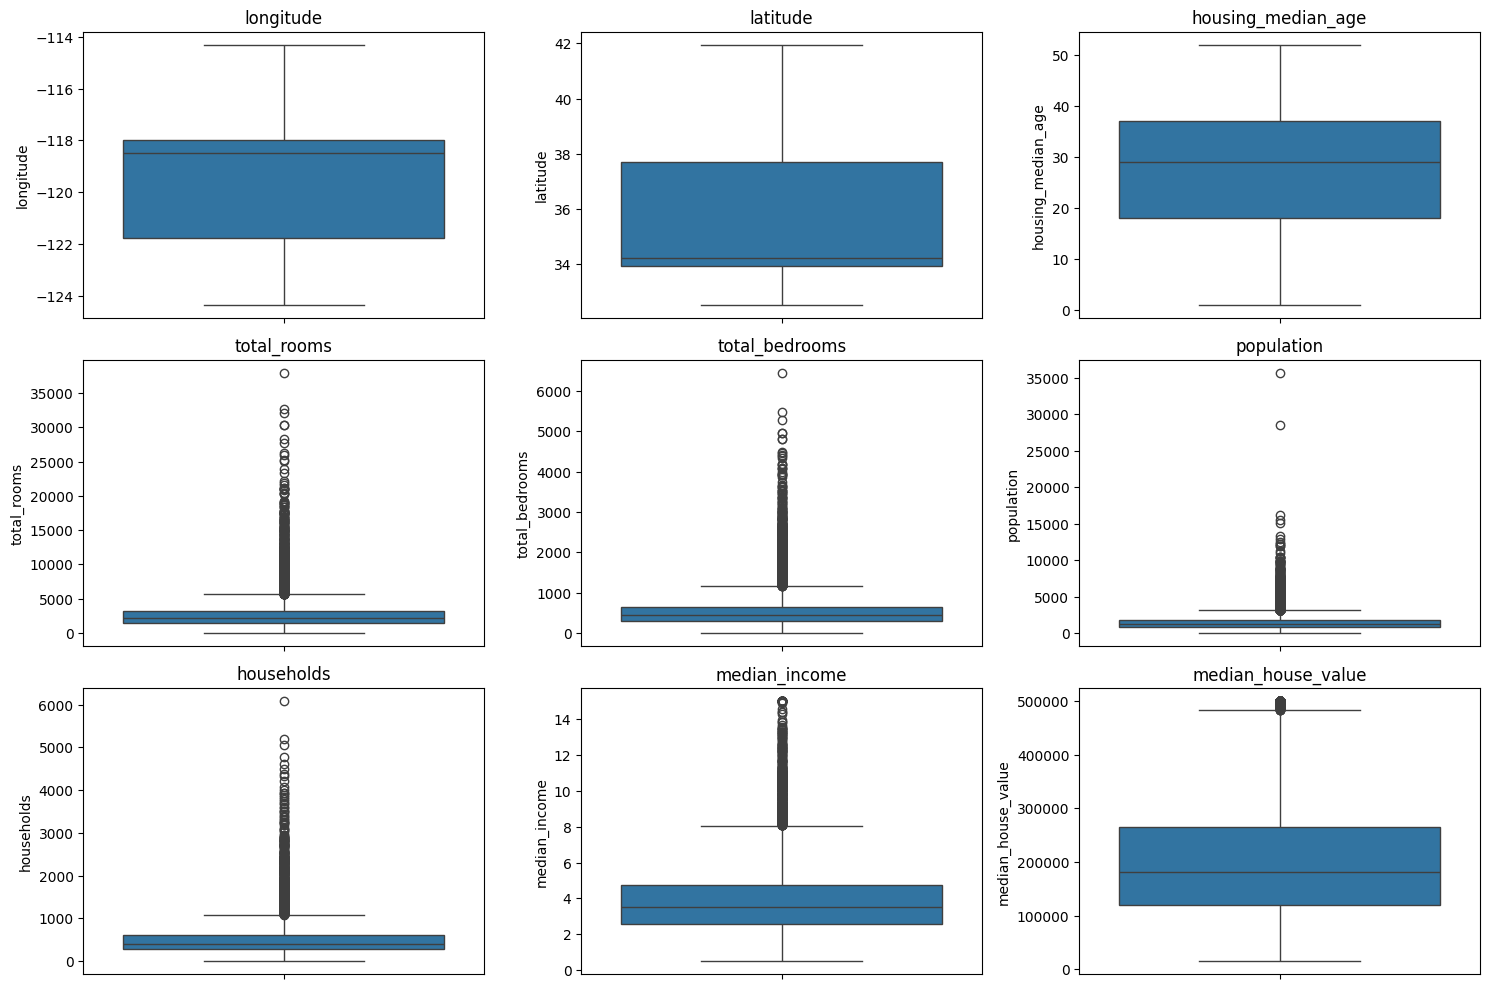

In [9]:
# Boxplot untuk mendeteksi outliers
fig, axes = plt.subplots(3, 3, figsize=(15,10))

for ax, col in zip(axes.flatten(), df.columns):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [10]:
# Quartile Range (IQR) untuk mendeteksi outliers
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask_outlier = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = mask_outlier.sum()

    percentage = outlier_count / len(df) * 100
    print(f"{col} - Outliers: ({percentage:.2f}%)")


longitude - Outliers: (0.00%)
latitude - Outliers: (0.00%)
housing_median_age - Outliers: (0.00%)
total_rooms - Outliers: (6.33%)
total_bedrooms - Outliers: (6.32%)
population - Outliers: (5.97%)
households - Outliers: (6.07%)
median_income - Outliers: (3.31%)
median_house_value - Outliers: (5.26%)


Berdasarkan visualisasi boxplot dan Interquartile Range IQR, didapatkan bahwa variable target pada kolom ```total_rooms ```, ```total_bedrooms```, ```population```, dan ```households``` memiliki outlier yang berkisar antara 5% - 6.5%. Mengingat variabel-variabel tersebut merepresentasikan karakteristik kawasan tempat tinggal, nilai ekstrem tersebut kemungkinan berasal dari wilayah dengan kepadatan penduduk tinggi atau jumlah unit hunian yang besar sehingga masih dapat dianggap sebagai representasi kondisi nyata dan bukan kesalahan pencatatan data. Sehingga apabila ada populations yang mencapai angka sangat jauh dari rata-rata yang didapat, dapat diindikasikan bahwa rumah tersebut berada dari kawasan padat penduduk. Variabel       ```median_income``` memiliki persentase outlier sebesar 3,31%, yang mengindikasikan keberadaan sejumlah wilayah dengan tingkat pendapatan yang jauh lebih tinggi dibandingkan mayoritas penduduk yang ada dan ```median_house_value``` memiliki sekitar 5.26% outlier yang mengindikasi adanya rumah dengan harga yang sangat tinggi pada lokasi-lokasi tertent. 

**KESIMPULAN**

Berdasarkan analisis outlier menggunakan metode Interquartile Range (IQR), sebagian besar variabel numerik menunjukkan keberadaan outlier dengan persentase berkisar antara 3% hingga 6%. Persentase tersebut masih tergolong relatif rendah dan tidak mendominasi dataset secara keseluruhan. Selain itu, mengingat konteks data yang merepresentasikan karakteristik wilayah perumahan di California, nilai-nilai ekstrem tersebut kemungkinan merupakan observasi valid yang mencerminkan kondisi nyata, seperti kawasan dengan jumlah penduduk tinggi, jumlah unit hunian besar, tingkat pendapatan tinggi, maupun harga rumah yang jauh di atas rata-rata. Oleh karena itu, seluruh observasi dipertahankan dan tidak dilakukan penghapusan outlier pada tahap data cleaning.

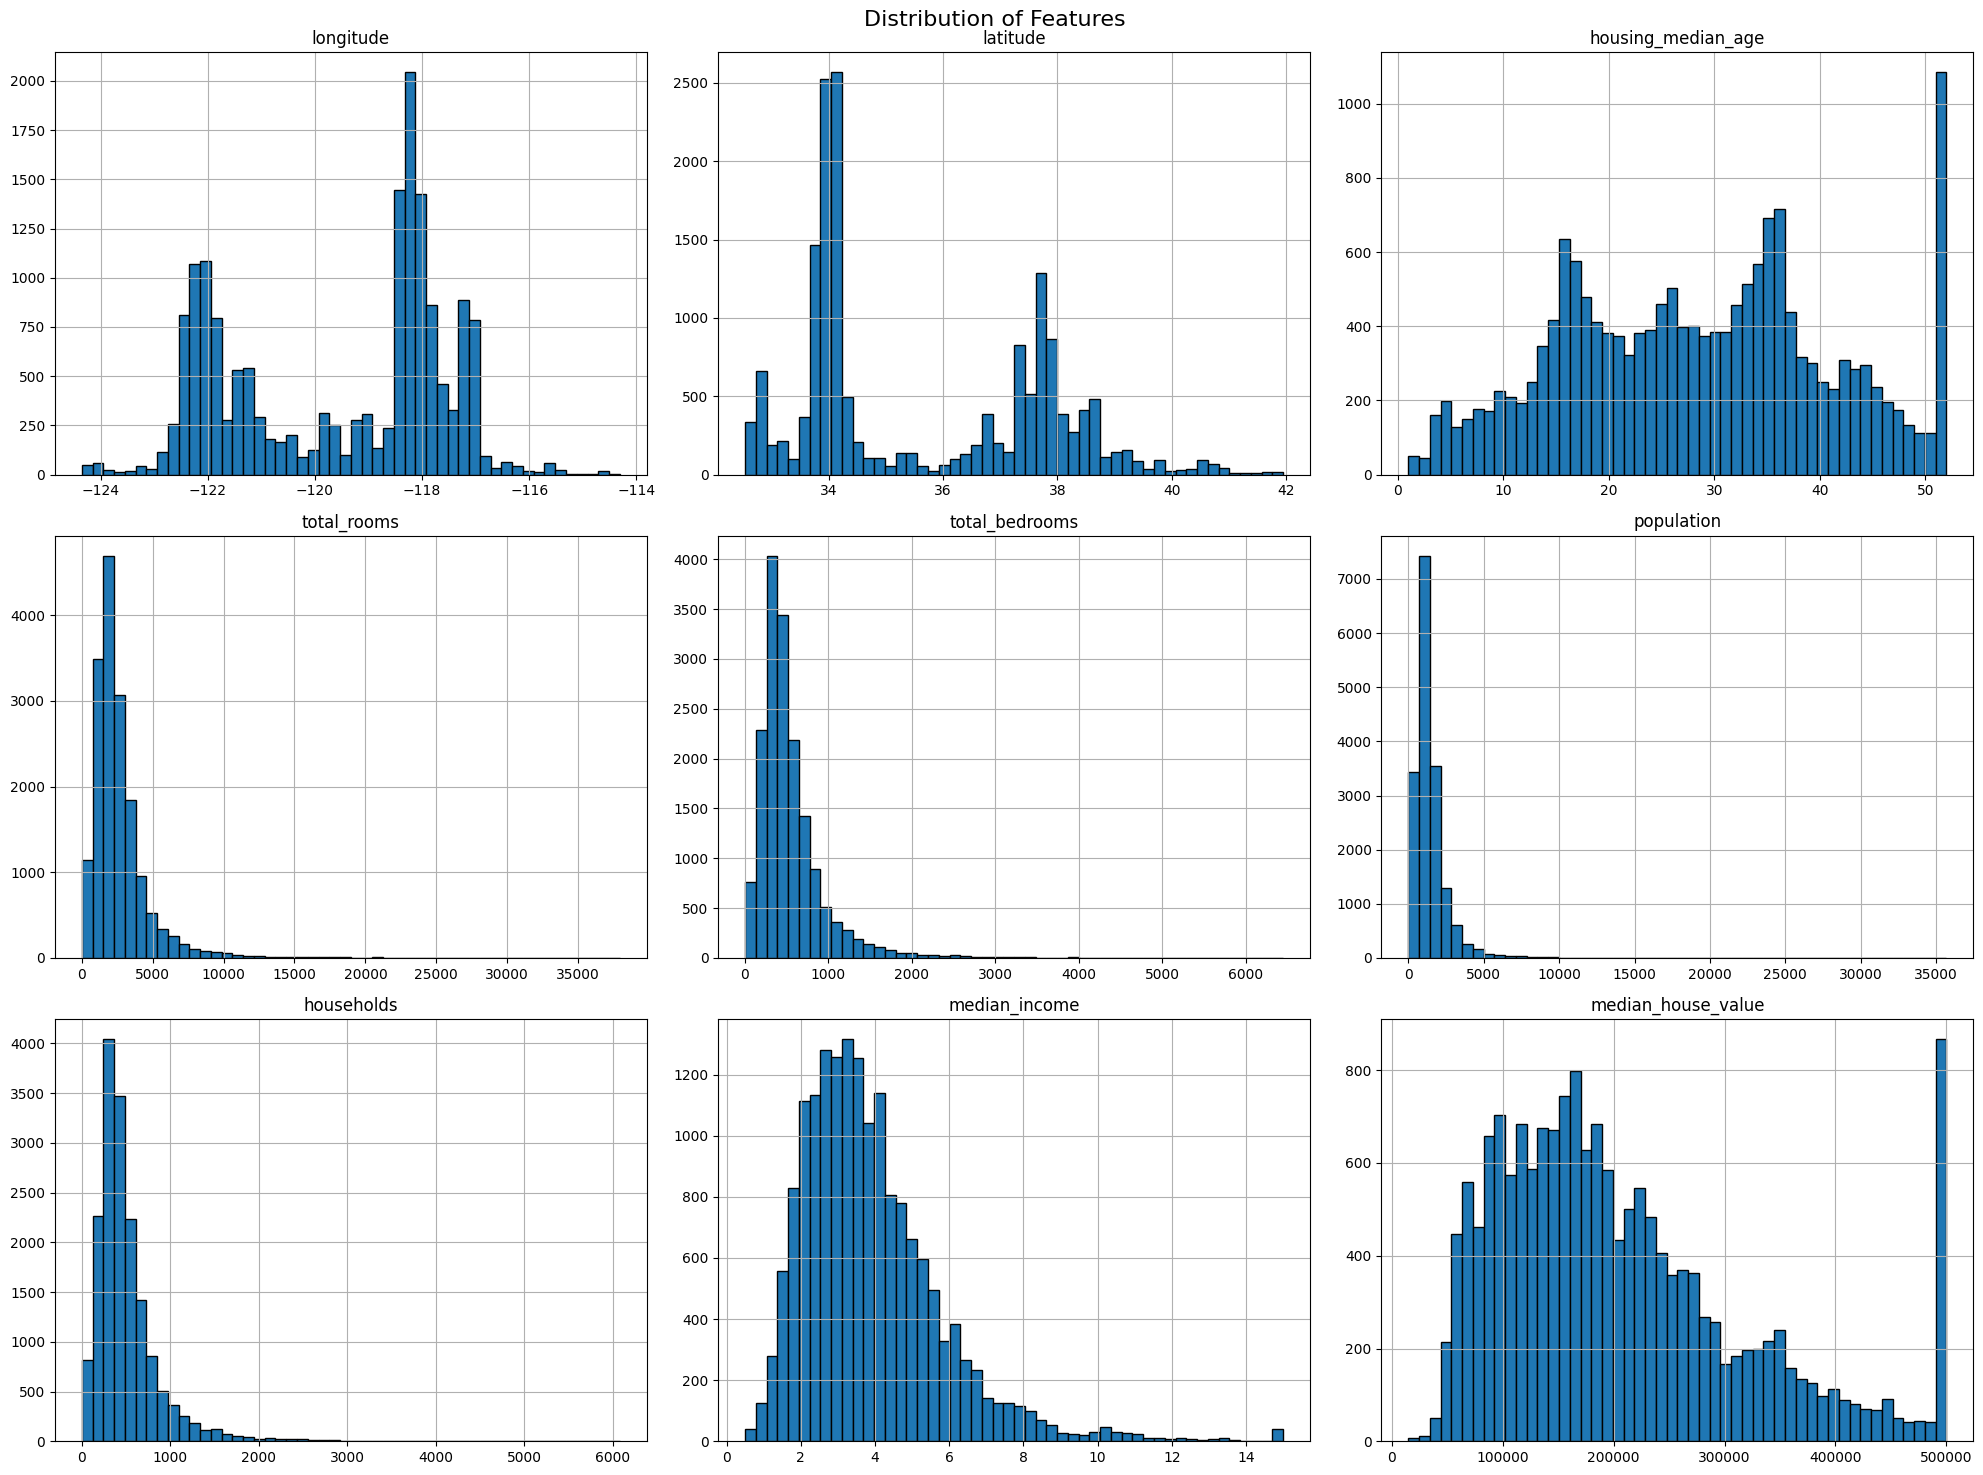

In [11]:
# Check Distribution of Target Variable
df.hist(bins=50, figsize=(20,15), edgecolor='black')
plt.suptitle("Distribution of Features", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
# Multicolinearity Check by VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X_vif = add_constant(df)

vif_df = pd.DataFrame(
    [vif(X_vif.values, i)
     for i in range(X_vif.shape[1])],
    index=X_vif.columns
).reset_index()

vif_df.columns = ['feature', 'vif_score']
vif_df = vif_df.loc[vif_df.feature != 'const']

vif_df

,feature,vif_score
1,longitude,10.377981
2,latitude,10.692828
3,housing_median_age,1.306410
4,total_rooms,12.527285
5,total_bedrooms,37.476511
6,population,6.929793
7,households,37.199237
8,median_income,2.976333
9,median_house_value,2.788139


<Axes: >

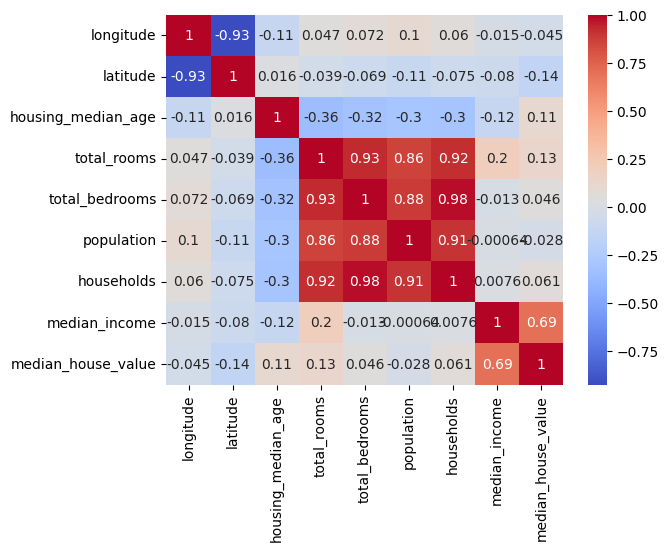

In [13]:
# Multicolinearity Check by Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

Berdasarkan nilai VIF dan gambar heatmap tersebut, variable `longitude`, `latitude`, `total_rooms`, `total_bedrooms`, dan `households` memilki risiko terjadinya multikolinearitas. Population juga kemungkinan terjadi, namun karena nilai VIF-nya rendah maka tidak akan berpengaruh signifikan. Sehingga, akan dilakukan penghapusan terhadap variable-variable yang memiliki korelasi lebih rendah dengan median_house_value sebagai target variable-nya. Variable yang akan dihapus yakni `longitude`, `total_bedrooms`, dan `households` karena sama-sama memiliki korelasi yang rendah terhadap variable target.

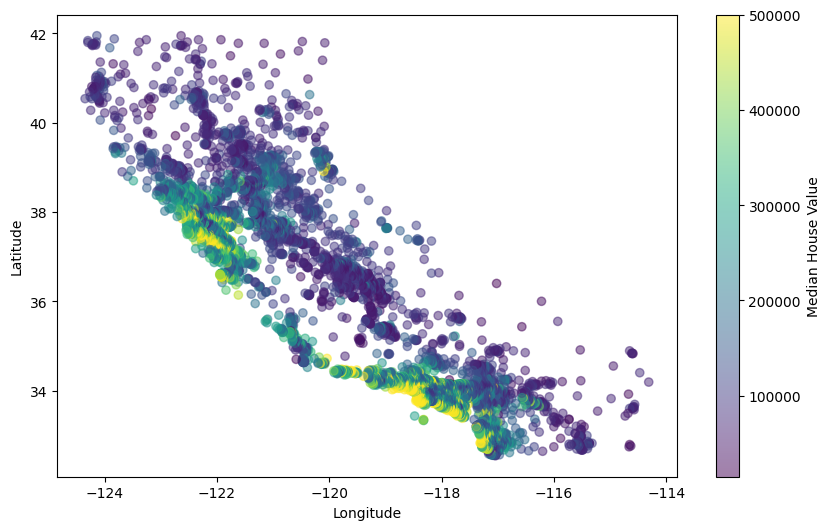

In [14]:
# Georgaphical Analysis
plt.figure(figsize=(10,6))
plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()